## 1. Conexión con Google Drive

In [35]:
# Conexión y configuración

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

DATOS_DIR = Path("/content/drive/MyDrive/UMSS/Diplomado/Modulo 6/Data")

BASE_DIR = Path("/content")
FIGURAS_DIR = BASE_DIR / "figuras_eda"
TABLAS_DIR = BASE_DIR / "tablas_eda"

FIGURAS_DIR.mkdir(exist_ok=True)
TABLAS_DIR.mkdir(exist_ok=True)

print("Ruta:", DATOS_DIR)
print("¿Existe?:", DATOS_DIR.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ruta: /content/drive/MyDrive/UMSS/Diplomado/Modulo 6/Data
¿Existe?: True


In [36]:
# Verificar archivos

csv_paths = sorted(DATOS_DIR.glob("*.csv"))

print(f"CSV encontrados: {len(csv_paths)}\n")

for p in csv_paths:
    print("-", p.name)

if not csv_paths:
    raise FileNotFoundError(
        "No se encontraron archivos CSV en la carpeta Data."
    )

CSV encontrados: 16

- diccionario_datos.csv
- dim_equipos.csv
- dim_sensores.csv
- dim_tecnicos.csv
- dim_turnos.csv
- hechos_alertas.csv
- hechos_consumos.csv
- hechos_fallas.csv
- hechos_horario_tecnico.csv
- hechos_mediciones_sensores.csv
- hechos_ordenes_trabajo.csv
- hechos_ordenes_trabajo_correctivas.csv
- hechos_revisiones_equipos.csv
- lista_equipos_origen.csv
- observaciones_diarias_equipo.csv
- relaciones_entidades.csv


In [37]:
# Cargar datasets


def leer_csv(ruta):
    return pd.read_csv(
        ruta,
        encoding="utf-8-sig",
        low_memory=False
    )

datos = {}

for ruta in csv_paths:
    datos[ruta.name] = leer_csv(ruta)

for nombre, df in datos.items():
    print(
        f"{nombre}: "
        f"{len(df):,} registros x "
        f"{df.shape[1]:,} variables"
    )

diccionario_datos.csv: 140 registros x 5 variables
dim_equipos.csv: 29 registros x 13 variables
dim_sensores.csv: 232 registros x 11 variables
dim_tecnicos.csv: 46 registros x 4 variables
dim_turnos.csv: 3 registros x 4 variables
hechos_alertas.csv: 4,090 registros x 8 variables
hechos_consumos.csv: 17,719 registros x 9 variables
hechos_fallas.csv: 278 registros x 10 variables
hechos_horario_tecnico.csv: 28,106 registros x 6 variables
hechos_mediciones_sensores.csv: 141,752 registros x 16 variables
hechos_ordenes_trabajo.csv: 17,719 registros x 10 variables
hechos_ordenes_trabajo_correctivas.csv: 278 registros x 13 variables
hechos_revisiones_equipos.csv: 17,719 registros x 11 variables
lista_equipos_origen.csv: 29 registros x 1 variables
observaciones_diarias_equipo.csv: 17,719 registros x 19 variables
relaciones_entidades.csv: 11 registros x 5 variables


## 2. Inventario general

In [38]:
inventario = pd.DataFrame([
    {
        "Archivo": nombre,
        "Registros": len(df),
        "Variables": df.shape[1]
    }
    for nombre, df in datos.items()
]).sort_values("Archivo").reset_index(drop=True)

display(inventario)

inventario.to_csv(
    TABLAS_DIR / "01_inventario.csv",
    index=False,
    encoding="utf-8-sig"
)

,Archivo,Registros,Variables
0,diccionario_datos.csv,140,5
1,dim_equipos.csv,29,13
2,dim_sensores.csv,232,11
3,dim_tecnicos.csv,46,4
4,dim_turnos.csv,3,4
5,hechos_alertas.csv,4090,8
6,hechos_consumos.csv,17719,9
7,hechos_fallas.csv,278,10
8,hechos_horario_tecnico.csv,28106,6
9,hechos_mediciones_sensores.csv,141752,16


## 3. Variables y tipos de datos

In [39]:
estructura = []

for nombre, df in datos.items():
    for col in df.columns:
        estructura.append({
            "Archivo": nombre,
            "Variable": col,
            "Tipo_Dato": str(df[col].dtype),
            "Nulos": int(df[col].isna().sum()),
            "Porcentaje_Nulos": round(df[col].isna().mean()*100, 2),
            "Valores_Unicos": int(df[col].nunique(dropna=True))
        })

estructura = pd.DataFrame(estructura)

display(estructura)

estructura.to_csv(
    TABLAS_DIR / "02_variables_tipos_calidad.csv",
    index=False,
    encoding="utf-8-sig"
)

,Archivo,Variable,Tipo_Dato,Nulos,Porcentaje_Nulos,Valores_Unicos
0,diccionario_datos.csv,Archivo,object,0,0.0,15
1,diccionario_datos.csv,Variable,object,0,0.0,83
2,diccionario_datos.csv,Tipo_Dato,object,0,0.0,4
3,diccionario_datos.csv,Descripcion,object,0,0.0,73
4,diccionario_datos.csv,Ejemplo,object,0,0.0,85
...,...,...,...,...,...,...
140,relaciones_entidades.csv,Entidad_Origen,object,0,0.0,5
141,relaciones_entidades.csv,Clave_Origen,object,0,0.0,5
142,relaciones_entidades.csv,Entidad_Destino,object,0,0.0,9
143,relaciones_entidades.csv,Clave_Destino,object,0,0.0,5


## 4. Diccionario de datos

In [40]:
diccionario = datos.get("diccionario_datos.csv")

if diccionario is not None:
    display(diccionario)
else:
    print("No se encontró diccionario_datos.csv")

,Archivo,Variable,Tipo_Dato,Descripcion,Ejemplo
0,hechos_consumos.csv,Identificador_Consumo,object,Identificador único del consumo.,CON-0000001
1,hechos_consumos.csv,Identificador_Equipo,int64,Identificador numérico único de seis dígitos d...,512413
2,hechos_consumos.csv,Codigo_Equipo_Origen,object,Código operativo del equipo proveniente de la ...,B11-203ERC001(1).xlsx
3,hechos_consumos.csv,Nombre_Equipo,object,Nombre descriptivo del equipo industrial.,Congelador industrial 01
4,hechos_consumos.csv,Fecha_Consumo,object,Fecha del consumo.,2025-01-01
...,...,...,...,...,...
135,observaciones_diarias_equipo.csv,Conjunto_Temporal,object,"Partición cronológica: Entrenamiento, Validaci...",Entrenamiento
136,dim_tecnicos.csv,Identificador_Tecnico,object,Identificador del técnico responsable de la me...,TECNICO_0001
137,dim_tecnicos.csv,Ficha_Tecnico,int64,Número de ficha del técnico.,1027
138,dim_tecnicos.csv,Nombre_Tecnico,object,Nombre del técnico.,GARNICA PELAEZ PABLO ALEJANDRO


## 5. Calidad: valores faltantes y duplicados

In [41]:
faltantes = estructura[
    estructura["Nulos"] > 0
].sort_values(
    "Porcentaje_Nulos",
    ascending=False
)

print("Variables con valores faltantes:")
display(faltantes)

faltantes.to_csv(
    TABLAS_DIR / "03_valores_faltantes.csv",
    index=False,
    encoding="utf-8-sig"
)

duplicados = pd.DataFrame([
    {
        "Archivo": nombre,
        "Registros": len(df),
        "Duplicados_Completos": int(df.duplicated().sum()),
        "Porcentaje_Duplicados": round(
            df.duplicated().mean()*100, 2
        ) if len(df) else 0
    }
    for nombre, df in datos.items()
])

print("Registros duplicados:")
display(duplicados)

duplicados.to_csv(
    TABLAS_DIR / "04_duplicados.csv",
    index=False,
    encoding="utf-8-sig"
)

Variables con valores faltantes:


,Archivo,Variable,Tipo_Dato,Nulos,Porcentaje_Nulos,Valores_Unicos
137,observaciones_diarias_equipo.csv,Falla_En_Los_Siguientes_Siete_Dias,float64,203,1.15,2


Registros duplicados:


,Archivo,Registros,Duplicados_Completos,Porcentaje_Duplicados
0,diccionario_datos.csv,140,0,0.0
1,dim_equipos.csv,29,0,0.0
2,dim_sensores.csv,232,0,0.0
3,dim_tecnicos.csv,46,0,0.0
4,dim_turnos.csv,3,0,0.0
5,hechos_alertas.csv,4090,0,0.0
6,hechos_consumos.csv,17719,0,0.0
7,hechos_fallas.csv,278,0,0.0
8,hechos_horario_tecnico.csv,28106,0,0.0
9,hechos_mediciones_sensores.csv,141752,0,0.0


## 6. Revisión de fechas y categorías

In [42]:
fechas = []

for nombre, df in datos.items():
    for col in df.columns:
        if "fecha" in col.lower() or "hora" in col.lower():
            s = pd.to_datetime(df[col], errors="coerce")

            fechas.append({
                "Archivo": nombre,
                "Variable": col,
                "Convertibles": int(s.notna().sum()),
                "No_Convertibles": int(s.isna().sum()),
                "Minimo": s.min(),
                "Maximo": s.max()
            })

fechas = pd.DataFrame(fechas)
display(fechas)

fechas.to_csv(
    TABLAS_DIR / "05_revision_fechas.csv",
    index=False,
    encoding="utf-8-sig"
)

# Categorías con hasta 20 valores
categorias = []

for nombre, df in datos.items():
    for col in df.select_dtypes(include="object").columns:
        if df[col].nunique(dropna=True) <= 20:
            for valor, cantidad in df[col].value_counts(dropna=False).items():
                categorias.append({
                    "Archivo": nombre,
                    "Variable": col,
                    "Valor": valor,
                    "Frecuencia": int(cantidad)
                })

categorias = pd.DataFrame(categorias)
display(categorias)

categorias.to_csv(
    TABLAS_DIR / "06_frecuencias_categoricas.csv",
    index=False,
    encoding="utf-8-sig"
)

,Archivo,Variable,Convertibles,No_Convertibles,Minimo,Maximo
0,dim_turnos.csv,Hora_Inicio,3,0,2026-09-09 06:00:00.000000000,2026-09-09 22:00:00.000000000
1,dim_turnos.csv,Hora_Fin,3,0,2026-09-09 06:00:00.000000000,2026-09-09 22:00:00.000000000
2,hechos_alertas.csv,Fecha_Alerta,4090,0,2025-01-04 00:00:00.000000000,2026-09-03 00:00:00.000000000
3,hechos_consumos.csv,Fecha_Consumo,17719,0,2025-01-01 00:00:00.000000000,2026-09-03 00:00:00.000000000
4,hechos_fallas.csv,Fecha_Falla,278,0,2025-01-31 00:00:00.000000000,2026-08-25 00:00:00.000000000
5,hechos_horario_tecnico.csv,Fecha,28106,0,2025-01-01 00:00:00.000000000,2026-09-03 00:00:00.000000000
6,hechos_horario_tecnico.csv,Hora_Entrada_Programada,28106,0,2026-09-09 06:00:00.000000000,2026-09-09 14:00:00.000000000
7,hechos_mediciones_sensores.csv,Fecha_Observacion,141752,0,2025-01-01 00:00:00.000000000,2026-09-03 00:00:00.000000000
8,hechos_mediciones_sensores.csv,Fecha_Hora_Medicion,141752,0,2025-01-01 07:00:00.000000000,2026-09-03 15:00:00.000000000
9,hechos_ordenes_trabajo.csv,Fecha_Orden,17719,0,2025-01-01 00:00:00.000000000,2026-09-03 00:00:00.000000000


,Archivo,Variable,Valor,Frecuencia
0,diccionario_datos.csv,Archivo,observaciones_diarias_equipo.csv,19
1,diccionario_datos.csv,Archivo,hechos_mediciones_sensores.csv,16
2,diccionario_datos.csv,Archivo,hechos_ordenes_trabajo_correctivas.csv,13
3,diccionario_datos.csv,Archivo,dim_equipos.csv,13
4,diccionario_datos.csv,Archivo,hechos_revisiones_equipos.csv,11
...,...,...,...,...
302,relaciones_entidades.csv,Clave_Destino,Identificador_Sensor,1
303,relaciones_entidades.csv,Clave_Destino,Identificador_Orden_Trabajo,1
304,relaciones_entidades.csv,Clave_Destino,Identificador_Falla,1
305,relaciones_entidades.csv,Cardinalidad,1:N,9


## 7. Estadística descriptiva

In [43]:
estadisticas = []

for nombre, df in datos.items():
    num = df.select_dtypes(include=np.number)

    if not num.empty:
        x = (
            num.describe()
            .T
            .reset_index()
            .rename(columns={"index":"Variable"})
        )
        x.insert(0, "Archivo", nombre)
        estadisticas.append(x)

estadisticas = pd.concat(
    estadisticas,
    ignore_index=True
)

display(estadisticas)

estadisticas.to_csv(
    TABLAS_DIR / "07_estadistica_descriptiva.csv",
    index=False,
    encoding="utf-8-sig"
)

,Archivo,Variable,count,mean,std,min,25%,50%,75%,max
0,dim_equipos.csv,Identificador_Equipo,29.0,5.486682e+05,2.247560e+05,195979.000,3.554550e+05,521462.000,6.927330e+05,965317.000
1,dim_equipos.csv,Año_Instalación,29.0,2.018759e+03,2.293705e+00,2016.000,2.017000e+03,2019.000,2.021000e+03,2023.000
2,dim_sensores.csv,Identificador_Sensor,232.0,5.384241e+06,2.541551e+06,1047667.000,3.174346e+06,5244207.500,7.632210e+06,9985531.000
3,dim_sensores.csv,Identificador_Equipo,232.0,5.486682e+05,2.213244e+05,195979.000,3.554550e+05,521462.000,6.927330e+05,965317.000
4,dim_tecnicos.csv,Ficha_Tecnico,46.0,2.429348e+03,1.246055e+03,1027.000,1.631500e+03,1724.500,4.165750e+03,4598.000
5,hechos_alertas.csv,Identificador_Equipo,4090.0,5.475771e+05,2.197426e+05,195979.000,3.554550e+05,521462.000,6.927330e+05,965317.000
6,hechos_consumos.csv,Identificador_Equipo,17719.0,5.486682e+05,2.208532e+05,195979.000,3.554550e+05,521462.000,6.927330e+05,965317.000
7,hechos_consumos.csv,Cantidad,17719.0,1.306908e+00,6.928001e-01,0.100,7.100000e-01,1.310,1.910000e+00,2.500
8,hechos_fallas.csv,Identificador_Equipo,278.0,5.469125e+05,2.193258e+05,195979.000,3.554550e+05,521462.000,6.927330e+05,965317.000
9,hechos_fallas.csv,Duracion_Parada_h,278.0,1.009245e+01,4.671727e+00,2.100,6.200000e+00,9.850,1.380000e+01,22.200


## 8. Dataset principal: Equipo-Día

In [44]:
obs = datos["observaciones_diarias_equipo.csv"].copy()

obs["Fecha_Observacion"] = pd.to_datetime(
    obs["Fecha_Observacion"],
    errors="coerce"
)

TARGET = "Falla_En_Los_Siguientes_Siete_Dias"

print("Registros:", f"{len(obs):,}")
print("Variables:", f"{obs.shape[1]:,}")
print(
    "Equipos:",
    f"{obs['Identificador_Equipo'].nunique():,}"
)
print("Fecha mínima:", obs["Fecha_Observacion"].min())
print("Fecha máxima:", obs["Fecha_Observacion"].max())

display(obs.head())

Registros: 17,719
Variables: 19
Equipos: 29
Fecha mínima: 2025-01-01 00:00:00
Fecha máxima: 2026-09-03 00:00:00


,Identificador_Equipo,Codigo_Equipo_Origen,Nombre_Equipo,Tipo_Equipo,Proceso,Línea,Criticidad,Fecha_Observacion,Temperatura_Proceso,Vibracion_Equipo,Presion_Sistema,Corriente_Motor,Caudal_Proceso,Nivel_Sistema,Velocidad_Accionamiento,Horas_Operacion,Falla_En_Los_Siguientes_Siete_Dias,Tiene_Horizonte_Completo_Siete_Dias,Conjunto_Temporal
0,195979,B11-101PAS002(1).xlsx,Pasteurizador 28,Pasteurizador,Preparación,Línea de Helados 04,Media,2025-01-01,3.597,1.353,2.201,36.918,107.417,76.549,1086.748,14467.554,0.0,True,Entrenamiento
1,195979,B11-101PAS002(1).xlsx,Pasteurizador 28,Pasteurizador,Preparación,Línea de Helados 04,Media,2025-01-02,4.325,1.269,1.753,36.312,105.476,76.555,1085.567,14480.743,0.0,True,Entrenamiento
2,195979,B11-101PAS002(1).xlsx,Pasteurizador 28,Pasteurizador,Preparación,Línea de Helados 04,Media,2025-01-03,4.622,1.493,1.931,34.722,106.308,78.915,1076.819,14494.670,0.0,True,Entrenamiento
3,195979,B11-101PAS002(1).xlsx,Pasteurizador 28,Pasteurizador,Preparación,Línea de Helados 04,Media,2025-01-04,3.645,1.343,1.804,38.140,106.048,76.921,1089.339,14504.778,0.0,True,Entrenamiento
4,195979,B11-101PAS002(1).xlsx,Pasteurizador 28,Pasteurizador,Preparación,Línea de Helados 04,Media,2025-01-05,3.429,0.889,1.707,39.587,102.167,76.094,1084.109,14517.505,0.0,True,Entrenamiento


In [45]:
# Unicidad Equipo-Día
duplicados_equipo_dia = obs.duplicated(
    ["Identificador_Equipo", "Fecha_Observacion"]
).sum()

print(
    "Duplicados Equipo-Día:",
    int(duplicados_equipo_dia)
)

print(
    "Unidad Equipo-Día única:",
    duplicados_equipo_dia == 0
)

Duplicados Equipo-Día: 0
Unidad Equipo-Día única: True


## 9. Variable objetivo

,Cantidad,Porcentaje
Falla_En_Los_Siguientes_Siete_Dias,,
0.0,15570,87.87
1.0,1946,10.98
NaN,203,1.15


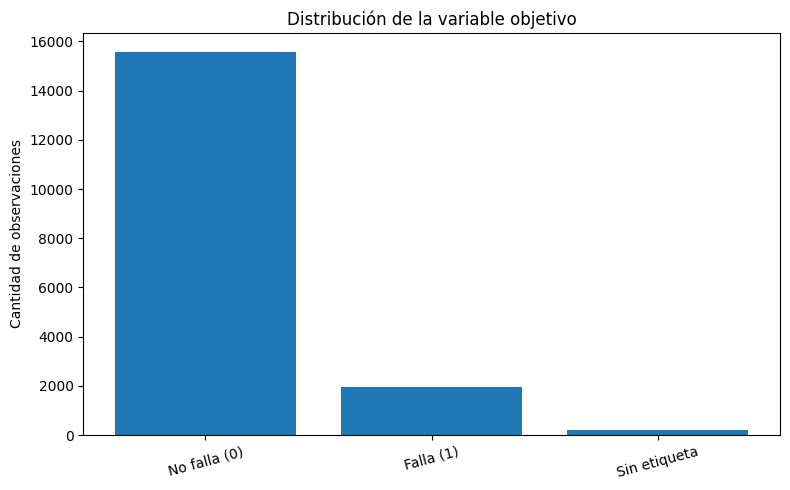

In [46]:
resumen_target = pd.DataFrame({
    "Cantidad": obs[TARGET].value_counts(dropna=False),
    "Porcentaje": (
        obs[TARGET]
        .value_counts(normalize=True, dropna=False)
        * 100
    ).round(2)
})

display(resumen_target)

resumen_target.to_csv(
    TABLAS_DIR / "08_variable_objetivo.csv",
    encoding="utf-8-sig"
)

n0 = int(obs[TARGET].eq(0).sum())
n1 = int(obs[TARGET].eq(1).sum())
ns = int(obs[TARGET].isna().sum())

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(
    ["No falla (0)", "Falla (1)", "Sin etiqueta"],
    [n0, n1, ns]
)
ax.set_title("Distribución de la variable objetivo")
ax.set_ylabel("Cantidad de observaciones")
plt.xticks(rotation=15)
plt.tight_layout()

fig.savefig(
    FIGURAS_DIR / "01_variable_objetivo.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 10. Distribución de variables de operación

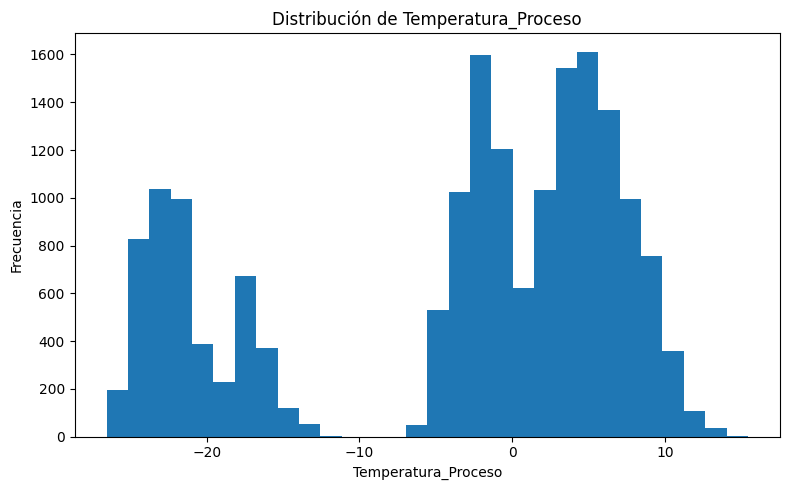

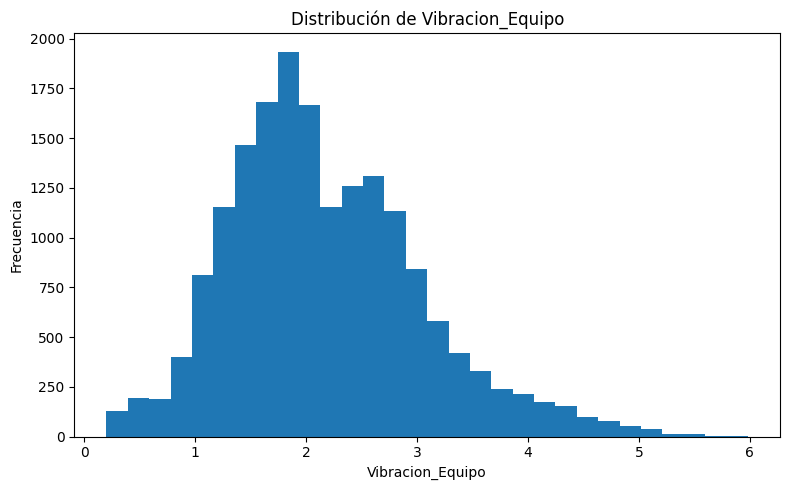

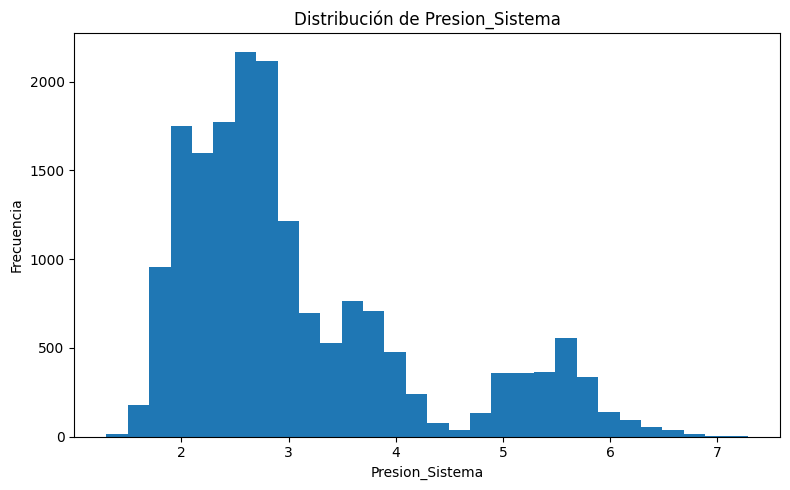

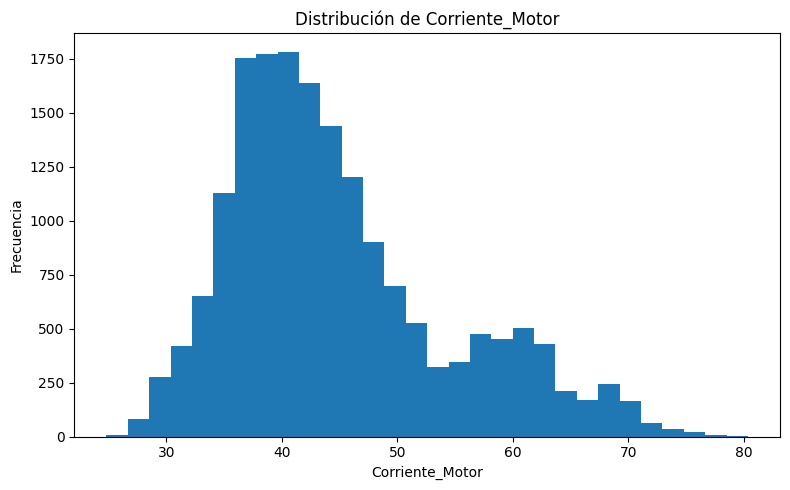

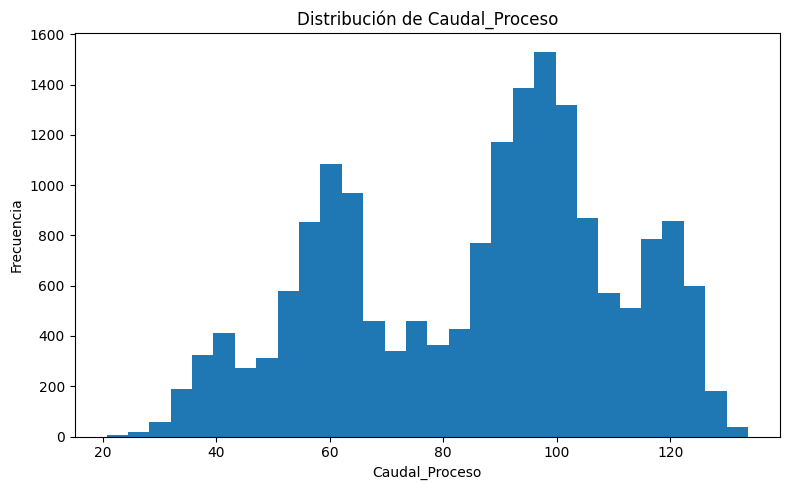

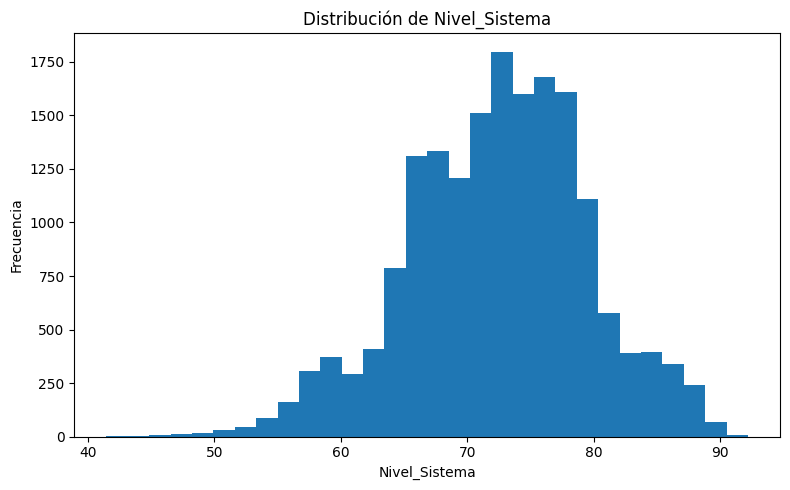

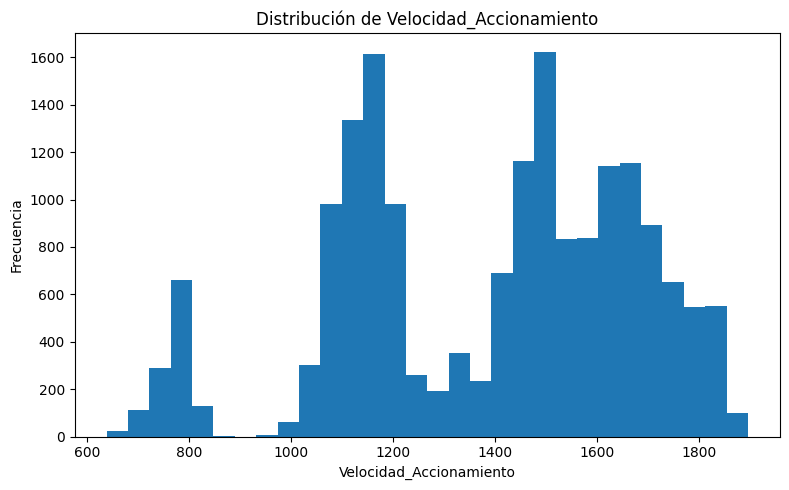

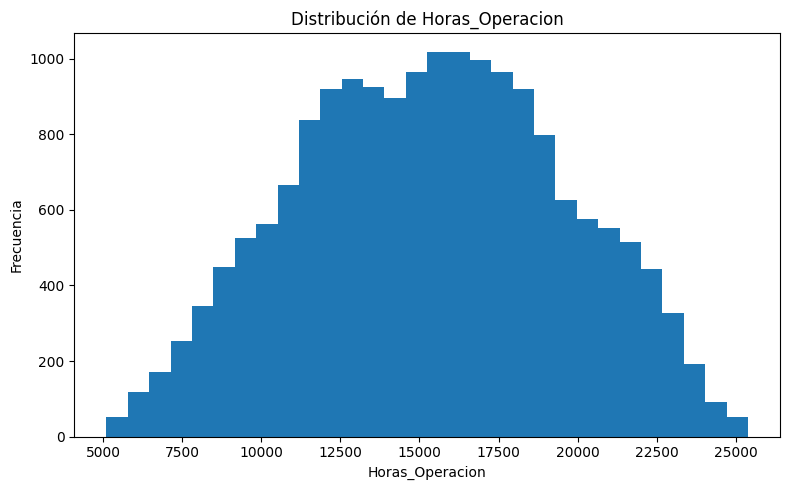

In [47]:
variables_operativas = [
    "Temperatura_Proceso",
    "Vibracion_Equipo",
    "Presion_Sistema",
    "Corriente_Motor",
    "Caudal_Proceso",
    "Nivel_Sistema",
    "Velocidad_Accionamiento",
    "Horas_Operacion"
]

variables_operativas = [
    c for c in variables_operativas
    if c in obs.columns
]

for col in variables_operativas:

    serie = pd.to_numeric(
        obs[col],
        errors="coerce"
    ).dropna()

    fig, ax = plt.subplots(figsize=(8,5))
    ax.hist(serie, bins=30)

    ax.set_title(
        f"Distribución de {col}"
    )
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")

    plt.tight_layout()

    fig.savefig(
        FIGURAS_DIR / f"02_hist_{col}.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

## 11. Valores atípicos

In [48]:
outliers = []

for col in variables_operativas:

    s = pd.to_numeric(
        obs[col],
        errors="coerce"
    ).dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara = (
        (s < limite_inferior)
        | (s > limite_superior)
    )

    outliers.append({
        "Variable": col,
        "Q1": q1,
        "Mediana": s.median(),
        "Q3": q3,
        "Limite_Inferior": limite_inferior,
        "Limite_Superior": limite_superior,
        "Outliers": int(mascara.sum()),
        "Porcentaje_Outliers": round(
            mascara.mean()*100, 2
        )
    })

outliers = pd.DataFrame(outliers)

display(
    outliers.sort_values(
        "Porcentaje_Outliers",
        ascending=False
    )
)

outliers.to_csv(
    TABLAS_DIR / "09_outliers_IQR.csv",
    index=False,
    encoding="utf-8-sig"
)

,Variable,Q1,Mediana,Q3,Limite_Inferior,Limite_Superior,Outliers,Porcentaje_Outliers
2,Presion_Sistema,2.2900,2.731,3.5840,0.34900,5.52500,1150,6.49
3,Corriente_Motor,37.8760,42.556,49.4940,20.44900,66.92100,586,3.31
1,Vibracion_Equipo,1.5620,2.030,2.6960,-0.13900,4.39700,326,1.84
5,Nivel_Sistema,67.5775,72.854,77.2925,53.00500,91.86500,111,0.63
0,Temperatura_Proceso,-16.5545,-0.656,4.8245,-48.62300,36.89300,0,0.00
4,Caudal_Proceso,63.2785,91.687,103.4785,2.97850,163.77850,0,0.00
6,Velocidad_Accionamiento,1154.5605,1458.048,1625.0890,448.76775,2330.88175,0,0.00
7,Horas_Operacion,12198.1575,15403.376,18427.0615,2854.80150,27770.41750,0,0.00


## 12. Relaciones entre variables

,Temperatura_Proceso,Vibracion_Equipo,Presion_Sistema,Corriente_Motor,Caudal_Proceso,Nivel_Sistema,Velocidad_Accionamiento,Horas_Operacion
Temperatura_Proceso,1.000,0.035,-0.070,0.229,-0.193,-0.556,0.006,-0.099
Vibracion_Equipo,0.035,1.000,0.188,0.458,-0.194,-0.532,0.420,-0.066
Presion_Sistema,-0.070,0.188,1.000,0.702,0.211,-0.021,0.623,-0.062
Corriente_Motor,0.229,0.458,0.702,1.000,-0.207,-0.328,0.758,-0.132
Caudal_Proceso,-0.193,-0.194,0.211,-0.207,1.000,0.134,-0.011,0.287
Nivel_Sistema,-0.556,-0.532,-0.021,-0.328,0.134,1.000,-0.199,0.127
Velocidad_Accionamiento,0.006,0.420,0.623,0.758,-0.011,-0.199,1.000,-0.121
Horas_Operacion,-0.099,-0.066,-0.062,-0.132,0.287,0.127,-0.121,1.000


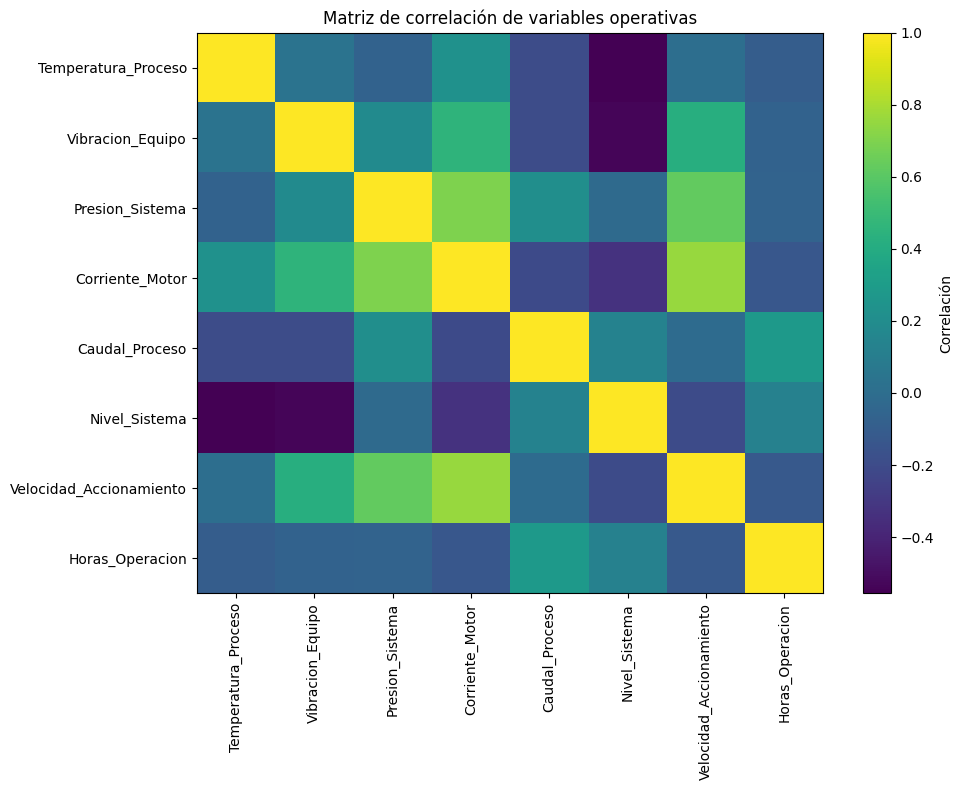

In [49]:
corr = obs[
    variables_operativas
].corr()

display(corr.round(3))

corr.to_csv(
    TABLAS_DIR / "10_matriz_correlacion.csv",
    encoding="utf-8-sig"
)

fig, ax = plt.subplots(figsize=(10,8))

im = ax.imshow(
    corr,
    aspect="auto"
)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))

ax.set_xticklabels(
    corr.columns,
    rotation=90
)
ax.set_yticklabels(
    corr.index
)

ax.set_title(
    "Matriz de correlación de variables operativas"
)

fig.colorbar(
    im,
    ax=ax,
    label="Correlación"
)

plt.tight_layout()

fig.savefig(
    FIGURAS_DIR / "03_matriz_correlacion.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 13. Variables operativas según ocurrencia de falla

In [50]:
etiquetados = obs[
    obs[TARGET].isin([0,1])
].copy()

comparacion = []

for col in variables_operativas:

    temp = etiquetados[
        [TARGET, col]
    ].copy()

    temp[col] = pd.to_numeric(
        temp[col],
        errors="coerce"
    )

    temp = temp.dropna()

    resumen = (
        temp.groupby(TARGET)[col]
        .agg(
            Cantidad="count",
            Media="mean",
            Mediana="median",
            Desviacion="std",
            Minimo="min",
            Maximo="max"
        )
        .reset_index()
    )

    resumen.insert(
        0,
        "Variable",
        col
    )

    comparacion.append(resumen)

comparacion = pd.concat(
    comparacion,
    ignore_index=True
)

display(comparacion)

comparacion.to_csv(
    TABLAS_DIR / "11_comparacion_por_falla.csv",
    index=False,
    encoding="utf-8-sig"
)

,Variable,Falla_En_Los_Siguientes_Siete_Dias,Cantidad,Media,Mediana,Desviacion,Minimo,Maximo
0,Temperatura_Proceso,0.0,15570,-4.159444,-0.9560,11.345824,-26.517,13.245
1,Temperatura_Proceso,1.0,1946,-1.514341,1.5520,11.153500,-23.421,15.435
2,Vibracion_Equipo,0.0,15570,1.995387,1.9310,0.702374,0.200,4.692
3,Vibracion_Equipo,1.0,1946,3.622275,3.5795,0.759112,1.345,5.983
4,Presion_Sistema,0.0,15570,3.034803,2.6940,1.115002,1.300,6.674
5,Presion_Sistema,1.0,1946,3.509002,3.1225,1.215762,1.909,7.288
6,Corriente_Motor,0.0,15570,44.278893,41.9895,9.492223,24.805,76.638
7,Corriente_Motor,1.0,1946,49.081659,46.8500,9.533031,31.063,80.340
8,Caudal_Proceso,0.0,15570,86.619089,92.4375,24.609839,25.335,133.699
9,Caudal_Proceso,1.0,1946,80.188848,86.1625,24.712932,20.696,125.159


## 14. Análisis temporal de fallas

,Mes,Cantidad_Fallas
0,2025-01,2
1,2025-02,15
2,2025-03,16
3,2025-04,13
4,2025-05,14
5,2025-06,10
6,2025-07,14
7,2025-08,18
8,2025-09,14
9,2025-10,14


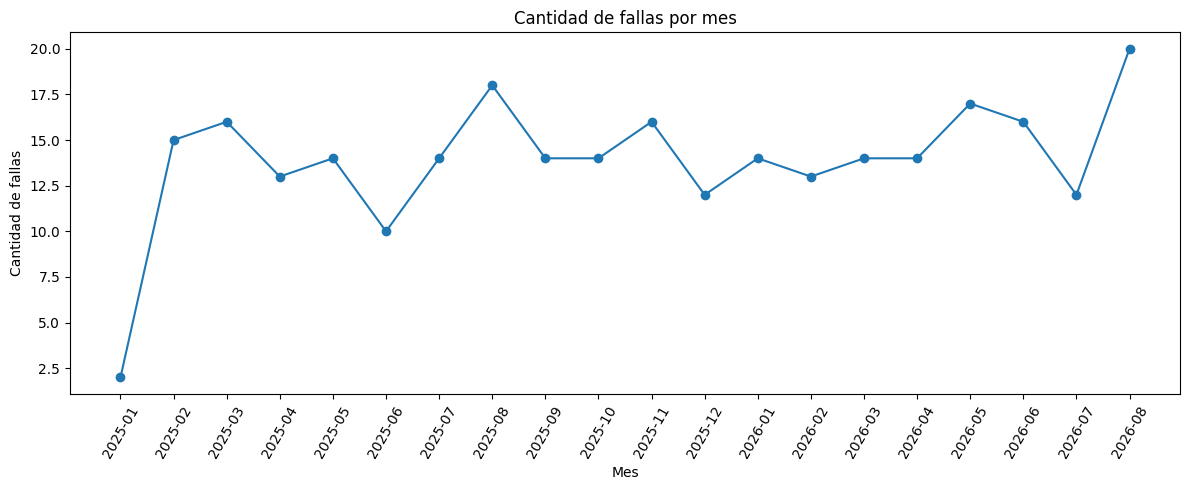

In [51]:
fallas = datos["hechos_fallas.csv"].copy()

fallas["Fecha_Falla"] = pd.to_datetime(
    fallas["Fecha_Falla"],
    errors="coerce"
)

fallas["Mes"] = (
    fallas["Fecha_Falla"]
    .dt.to_period("M")
    .astype(str)
)

fallas_mes = (
    fallas.groupby("Mes")
    .size()
    .reset_index(
        name="Cantidad_Fallas"
    )
)

display(fallas_mes)

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    fallas_mes["Mes"],
    fallas_mes["Cantidad_Fallas"],
    marker="o"
)

ax.set_title(
    "Cantidad de fallas por mes"
)
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de fallas")

plt.xticks(rotation=60)
plt.tight_layout()

fig.savefig(
    FIGURAS_DIR / "04_fallas_por_mes.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

fallas_mes.to_csv(
    TABLAS_DIR / "12_fallas_por_mes.csv",
    index=False,
    encoding="utf-8-sig"
)

,Identificador_Equipo,Cantidad_Fallas
1,251669,10
4,291860,10
8,375045,10
7,355455,10
6,355293,10
11,460500,10
10,435609,10
12,468365,10
9,398119,10
20,683583,10


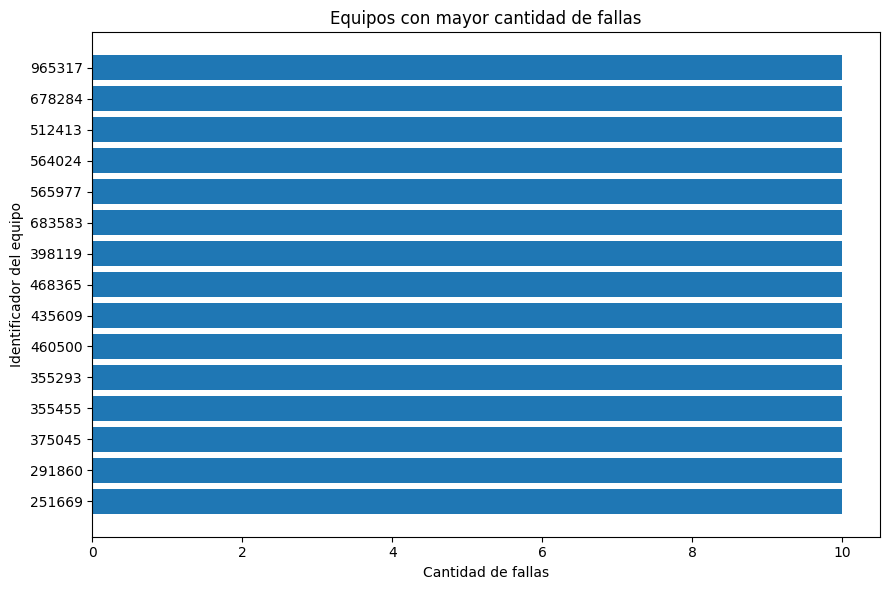

In [52]:
# Fallas por equipo
fallas_equipo = (
    fallas.groupby("Identificador_Equipo")
    .size()
    .reset_index(
        name="Cantidad_Fallas"
    )
    .sort_values(
        "Cantidad_Fallas",
        ascending=False
    )
)

display(fallas_equipo)

top = (
    fallas_equipo
    .head(15)
    .sort_values("Cantidad_Fallas")
)

fig, ax = plt.subplots(figsize=(9,6))

ax.barh(
    top["Identificador_Equipo"].astype(str),
    top["Cantidad_Fallas"]
)

ax.set_title(
    "Equipos con mayor cantidad de fallas"
)
ax.set_xlabel("Cantidad de fallas")
ax.set_ylabel("Identificador del equipo")

plt.tight_layout()

fig.savefig(
    FIGURAS_DIR / "05_fallas_por_equipo.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

fallas_equipo.to_csv(
    TABLAS_DIR / "13_fallas_por_equipo.csv",
    index=False,
    encoding="utf-8-sig"
)

## 15. Fallas por tipo de equipo y criticidad

In [53]:
equipos = datos["dim_equipos.csv"].copy()

fallas_info = fallas.merge(
    equipos[
        [
            "Identificador_Equipo",
            "Nombre_Equipo",
            "Tipo_Equipo",
            "Criticidad"
        ]
    ],
    on="Identificador_Equipo",
    how="left"
)

por_tipo = (
    fallas_info.groupby("Tipo_Equipo")
    .size()
    .reset_index(
        name="Cantidad_Fallas"
    )
    .sort_values(
        "Cantidad_Fallas",
        ascending=False
    )
)

por_criticidad = (
    fallas_info.groupby("Criticidad")
    .size()
    .reset_index(
        name="Cantidad_Fallas"
    )
    .sort_values(
        "Cantidad_Fallas",
        ascending=False
    )
)

print("Fallas por tipo de equipo")
display(por_tipo)

print("Fallas por criticidad")
display(por_criticidad)

por_tipo.to_csv(
    TABLAS_DIR / "14_fallas_por_tipo_equipo.csv",
    index=False,
    encoding="utf-8-sig"
)

por_criticidad.to_csv(
    TABLAS_DIR / "15_fallas_por_criticidad.csv",
    index=False,
    encoding="utf-8-sig"
)

Fallas por tipo de equipo


,Tipo_Equipo,Cantidad_Fallas
2,Congelador industrial,29
11,Túnel de congelación,29
6,Homogeneizador,29
7,Mezclador industrial,29
8,Pasteurizador,29
3,Cámara frigorífica,19
0,Bomba de circulación,19
1,Compresor de refrigeración,19
4,Dosificadora de helado,19
5,Envasadora automática,19


Fallas por criticidad


,Criticidad,Cantidad_Fallas
0,Alta,116
2,Media,114
1,Baja,48


## 16. Cobertura de sensores

In [54]:
sensores = datos["dim_sensores.csv"].copy()
mediciones = datos["hechos_mediciones_sensores.csv"].copy()

cobertura = (
    mediciones.groupby(
        [
            "Identificador_Sensor",
            "Tipo_Sensor",
            "Nombre_Sensor",
            "Identificador_Equipo"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="Cantidad_Mediciones"
    )
)

display(cobertura.head(50))

cobertura.to_csv(
    TABLAS_DIR / "16_cobertura_sensores.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Sensores por equipo:"
)
display(
    sensores.groupby(
        "Identificador_Equipo"
    ).size().value_counts().sort_index()
)

,Identificador_Sensor,Tipo_Sensor,Nombre_Sensor,Identificador_Equipo,Cantidad_Mediciones
0,1047667,Sensor de presión,Sensor de presión del sistema de congelación,678284,611
1,1052680,Sensor de velocidad,Sensor de velocidad del accionamiento,296570,611
2,1241271,Sensor de horas de operación,Sensor de horas de operación,398119,611
3,1285652,Sensor de vibración,Sensor de vibración del equipo,564024,611
4,1309808,Sensor de nivel,Sensor de nivel del sistema,887319,611
5,1322081,Sensor de horas de operación,Sensor de horas de operación,887319,611
6,1327626,Sensor de caudal,Sensor de caudal de congelación,279116,611
7,1347362,Sensor de corriente,Sensor de corriente del motor,565977,611
8,1382313,Sensor de caudal,Sensor de caudal de preparación,355455,611
9,1394887,Sensor de velocidad,Sensor de velocidad del accionamiento,435609,611


Sensores por equipo:


,count
8,29


## 17. Revisión de fuga de información

In [55]:
# Variables que no deben utilizarse como predictores sin justificación
variables_a_revisar = [
    TARGET,
    "Tiene_Horizonte_Completo_Siete_Dias",
    "Falla_Registrada",
    "Tipo_Falla",
    "Severidad",
    "Probabilidad_Falla_7_días_%",
    "Probabilidad_Falla_%",
    "Vida_Útil_Restante_días",
    "Falla_Confirmada"
]

presentes = [
    c for c in variables_a_revisar
    if c in obs.columns
]

print("Variables presentes que requieren revisión:")
for c in presentes:
    print("-", c)

print("\nRegla metodológica:")
print(
    "Una observación Equipo-Día utiliza únicamente información "
    "disponible hasta el cierre de ese día."
)
print(
    "La falla de los siete días posteriores se utiliza para construir "
    "la variable objetivo."
)

Variables presentes que requieren revisión:
- Falla_En_Los_Siguientes_Siete_Dias
- Tiene_Horizonte_Completo_Siete_Dias

Regla metodológica:
Una observación Equipo-Día utiliza únicamente información disponible hasta el cierre de ese día.
La falla de los siete días posteriores se utiliza para construir la variable objetivo.


## 18. Validación física de variables por proceso

Esta sección verifica los rangos observados de las principales variables operativas según el proceso. El objetivo no es eliminar automáticamente valores extremos, sino identificar comportamientos que requieran revisión en la Fase 3.

Variables operativas encontradas:
  ✓ Temperatura_Proceso
  ✓ Vibracion_Equipo
  ✓ Presion_Sistema
  ✓ Corriente_Motor
  ✓ Caudal_Proceso
  ✓ Nivel_Sistema
  ✓ Velocidad_Accionamiento
  ✓ Horas_Operacion

Rangos de variables por proceso


,Proceso,Variable,N,Mínimo,P25,Mediana,P75,Máximo
0,Almacenamiento,Temperatura_Proceso,1222,-19.783,-17.481,-16.908,-16.108,-12.242
1,Almacenamiento,Vibracion_Equipo,1222,0.200,0.569,0.929,1.226,4.203
2,Almacenamiento,Presion_Sistema,1222,1.300,1.895,2.082,2.287,2.976
3,Almacenamiento,Corriente_Motor,1222,24.805,31.054,34.606,37.254,47.754
4,Almacenamiento,Caudal_Proceso,1222,20.696,36.298,39.671,42.554,51.173
5,Almacenamiento,Nivel_Sistema,1222,66.705,81.718,84.035,86.787,92.194
6,Almacenamiento,Velocidad_Accionamiento,1222,638.294,753.719,775.251,794.594,862.674
7,Almacenamiento,Horas_Operacion,1222,8145.197,11787.748,13799.479,15716.909,19254.718
8,Congelación,Temperatura_Proceso,3666,-26.547,-23.914,-22.618,-21.458,-15.174
9,Congelación,Vibracion_Equipo,3666,1.212,1.812,2.005,2.340,5.109



Equipos por proceso


,Proceso,Cantidad_Equipos
0,Almacenamiento,2
1,Congelación,6
2,Envasado,8
3,Preparación,9
4,Refrigeración,4



Generando diagramas de caja...


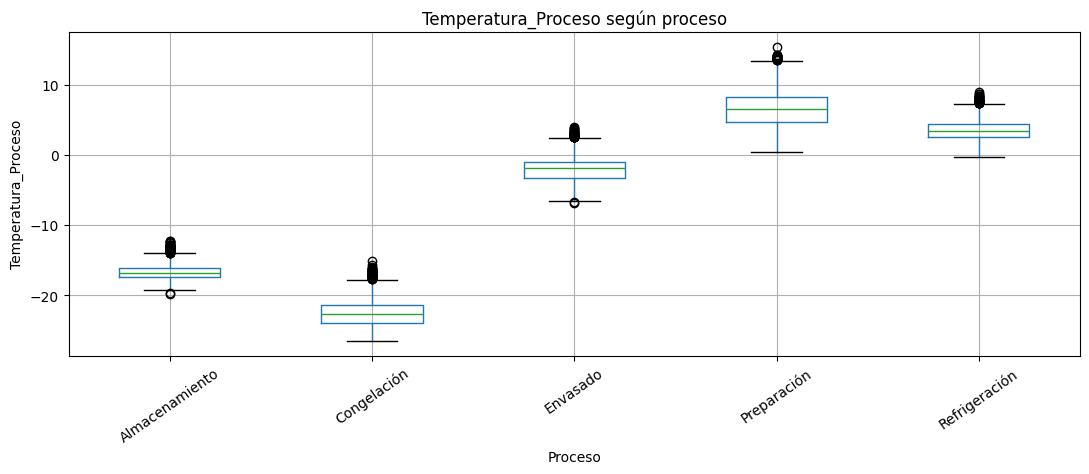

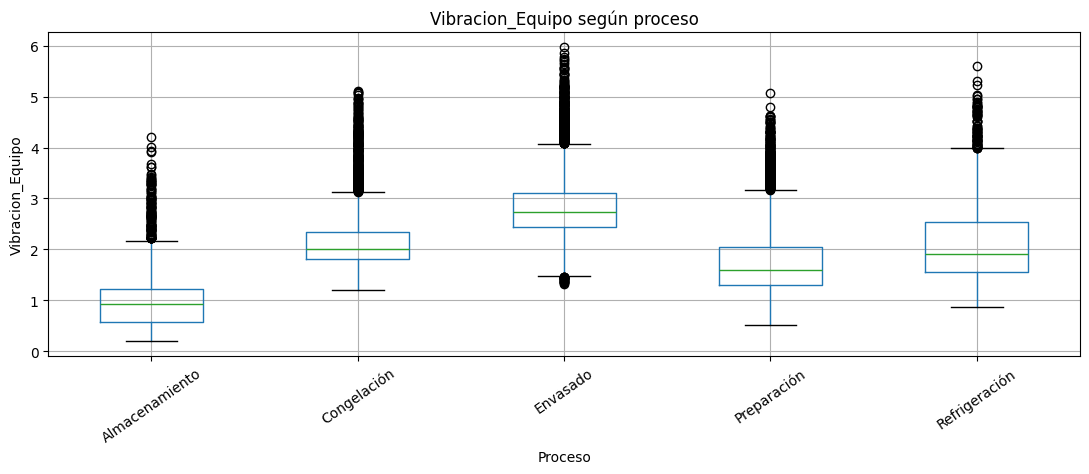

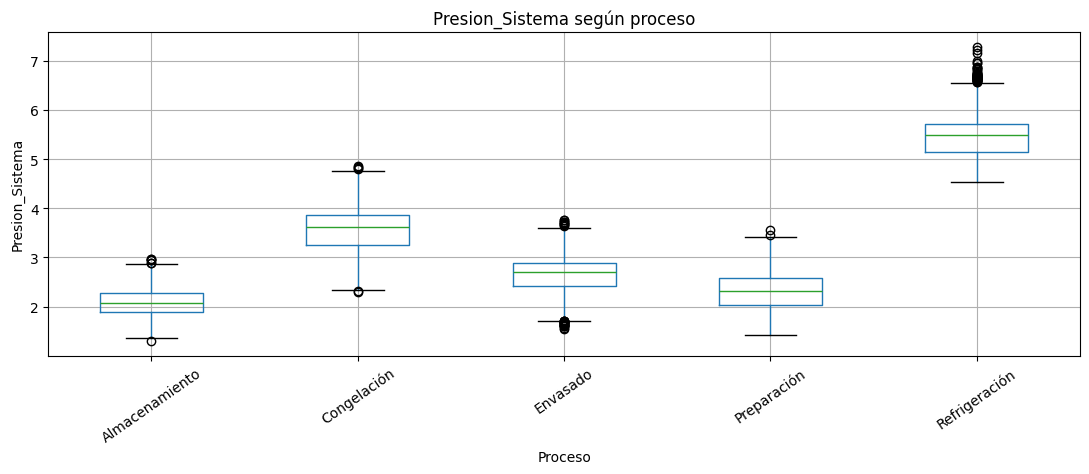

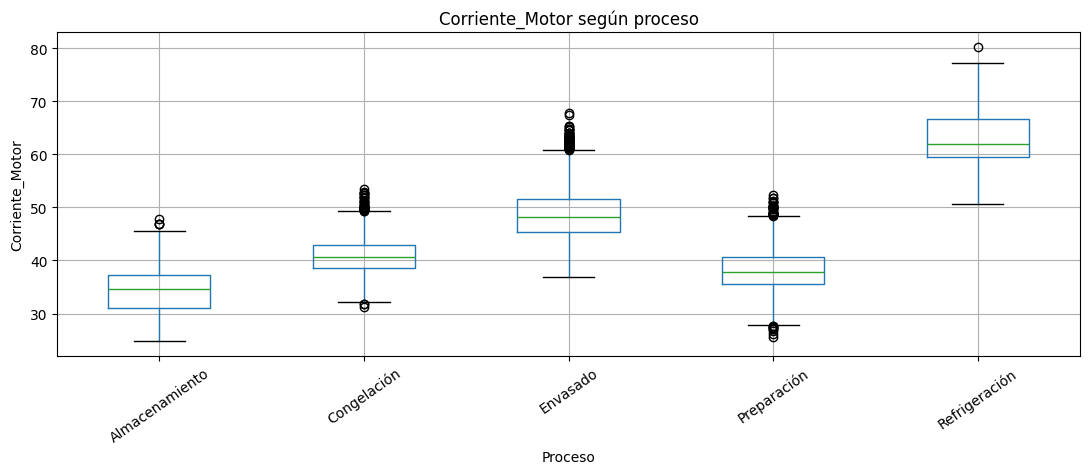


Validación física por proceso completada.


In [56]:
# Validación física por proceso

# Variables operativas

vars_operacion = [
    "Temperatura_Proceso",
    "Vibracion_Equipo",
    "Presion_Sistema",
    "Corriente_Motor",
    "Caudal_Proceso",
    "Nivel_Sistema",
    "Velocidad_Accionamiento",
    "Horas_Operacion"
]

vars_operacion = [
    v for v in vars_operacion
    if v in obs.columns
]

if "Proceso" not in obs.columns:
    raise KeyError(
        "La columna 'Proceso' no existe en observaciones_diarias_equipo.csv."
    )

print("Variables operativas encontradas:")
for v in vars_operacion:
    print(f"  ✓ {v}")

# Convertir variables a numéricas

for v in vars_operacion:
    obs[v] = pd.to_numeric(
        obs[v],
        errors="coerce"
    )

# Resumen por proceso

resumen_proceso = []

for proceso, grupo in obs.groupby(
    "Proceso",
    dropna=False
):
    for variable in vars_operacion:
        serie = grupo[variable].dropna()

        if len(serie) == 0:
            continue

        resumen_proceso.append({
            "Proceso": proceso,
            "Variable": variable,
            "N": len(serie),
            "Mínimo": serie.min(),
            "P25": serie.quantile(0.25),
            "Mediana": serie.median(),
            "P75": serie.quantile(0.75),
            "Máximo": serie.max()
        })

tabla_rangos_proceso = pd.DataFrame(
    resumen_proceso
)

print("\nRangos de variables por proceso")
display(tabla_rangos_proceso.round(3))

# Equipos por proceso

if "Identificador_Equipo" in obs.columns:
    equipos_proceso = (
        obs.groupby("Proceso")["Identificador_Equipo"]
        .nunique()
        .reset_index(name="Cantidad_Equipos")
    )

    print("\nEquipos por proceso")
    display(equipos_proceso)

# Gráficos de variables relevantes

variables_grafico = [
    "Temperatura_Proceso",
    "Vibracion_Equipo",
    "Presion_Sistema",
    "Corriente_Motor"
]

variables_grafico = [
    v for v in variables_grafico
    if v in obs.columns
]

print("\nGenerando diagramas de caja...")

for variable in variables_grafico:
    fig, ax = plt.subplots(figsize=(11, 5))

    obs.boxplot(
        column=variable,
        by="Proceso",
        rot=35,
        ax=ax
    )

    ax.set_title(f"{variable} según proceso")
    ax.set_xlabel("Proceso")
    ax.set_ylabel(variable)

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

print("\nValidación física por proceso completada.")


## 19. Distribución de fallas por equipo y proceso

Se analiza si los eventos de falla presentan una distribución excesivamente uniforme. Esta revisión es importante para interpretar la representatividad del conjunto de datos y evitar conclusiones que supongan una distribución histórica que no haya sido documentada.

Fallas por equipo


,Identificador_Equipo,Nombre_Equipo,Cantidad_Fallas
1,251669,Pasteurizador 04,10
4,291860,Homogeneizador 03,10
8,375045,Mezclador industrial 05,10
7,355455,Pasteurizador 16,10
6,355293,Dosificadora de helado 08,10
11,460500,Compresor de refrigeración 06,10
10,435609,Homogeneizador 15,10
12,468365,Cámara frigorífica 12,10
9,398119,Bomba de circulación 07,10
20,683583,Túnel de congelación 02,10



Estadísticas de fallas por equipo


,Cantidad_Fallas
count,29.00
mean,9.59
std,0.50
min,9.00
25%,9.00
50%,10.00
75%,10.00
max,10.00



Eventos sin proceso asociado: 0

Fallas por proceso


,Proceso,Cantidad_Fallas,Porcentaje
3,Preparación,87,31.29
2,Envasado,76,27.34
1,Congelación,58,20.86
4,Refrigeración,38,13.67
0,Almacenamiento,19,6.83


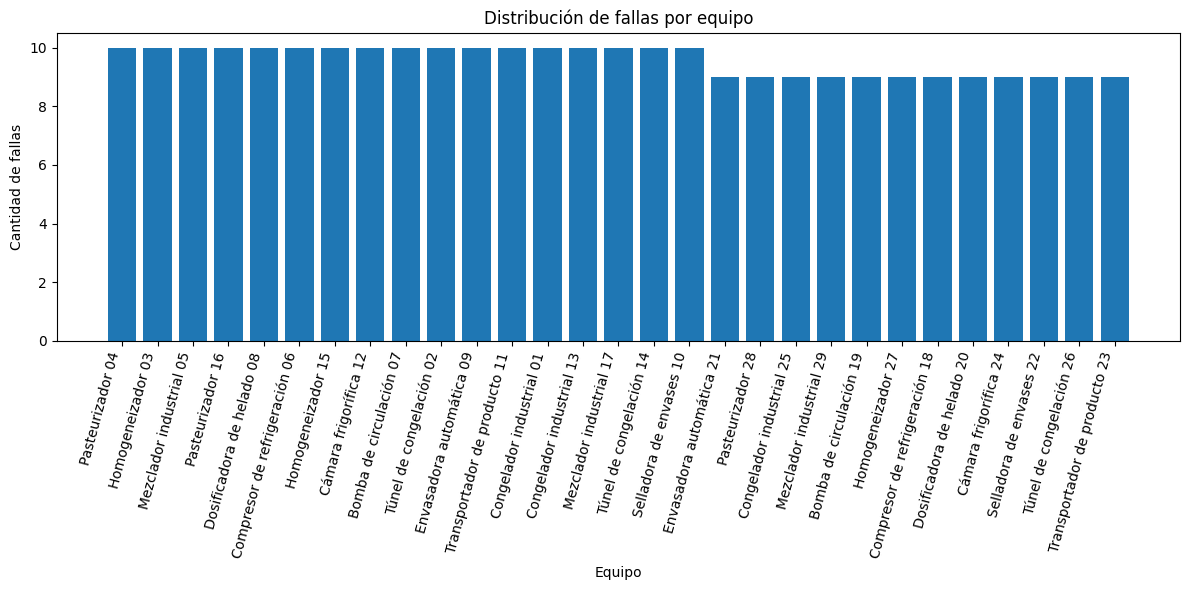

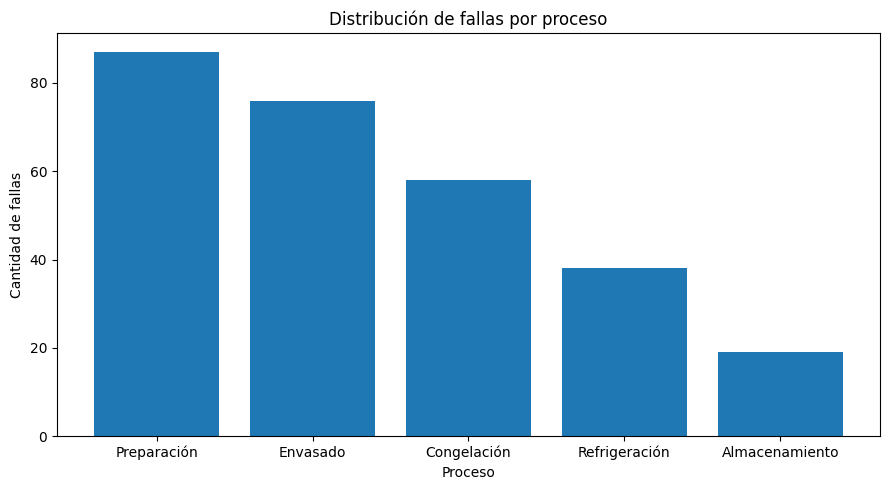


Análisis de distribución de fallas completado.


In [57]:
# Distribución de fallas por equipo y proceso

# Fallas por equipo

columnas_equipo = [
    c for c in [
        "Identificador_Equipo",
        "Equipo"
    ]
    if c in fallas.columns
]

if not columnas_equipo:
    raise KeyError(
        "No se encontró una columna de identificación del equipo."
    )

col_equipo = columnas_equipo[0]

if "Nombre_Equipo" in fallas.columns:
    fallas_equipo = (
        fallas
        .groupby(
            [col_equipo, "Nombre_Equipo"],
            dropna=False
        )
        .size()
        .reset_index(name="Cantidad_Fallas")
        .sort_values("Cantidad_Fallas", ascending=False)
    )
else:
    fallas_equipo = (
        fallas
        .groupby(
            col_equipo,
            dropna=False
        )
        .size()
        .reset_index(name="Cantidad_Fallas")
        .sort_values("Cantidad_Fallas", ascending=False)
    )

print("Fallas por equipo")
display(fallas_equipo)

# Estadísticas de fallas

estadisticas_fallas = (
    fallas_equipo["Cantidad_Fallas"]
    .describe()
    .round(2)
)

print("\nEstadísticas de fallas por equipo")
display(estadisticas_fallas)

# Relacionar fallas con el proceso

if (
    "Identificador_Equipo" not in fallas.columns
    or "Identificador_Equipo" not in equipos.columns
    or "Proceso" not in equipos.columns
):
    raise KeyError(
        "No existen las columnas necesarias para relacionar "
        "hechos_fallas con dim_equipos."
    )

fallas_proceso = fallas[
    ["Identificador_Equipo"]
].merge(
    equipos[
        ["Identificador_Equipo", "Proceso"]
    ].drop_duplicates("Identificador_Equipo"),
    on="Identificador_Equipo",
    how="left"
)

sin_proceso = fallas_proceso["Proceso"].isna().sum()

print(f"\nEventos sin proceso asociado: {sin_proceso:,}")

fallas_por_proceso = (
    fallas_proceso
    .groupby("Proceso", dropna=False)
    .size()
    .reset_index(name="Cantidad_Fallas")
    .sort_values("Cantidad_Fallas", ascending=False)
)

fallas_por_proceso["Porcentaje"] = (
    fallas_por_proceso["Cantidad_Fallas"]
    / fallas_por_proceso["Cantidad_Fallas"].sum()
    * 100
).round(2)

print("\nFallas por proceso")
display(fallas_por_proceso)

# Gráfico de fallas por equipo

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    fallas_equipo["Nombre_Equipo"].astype(str)
    if "Nombre_Equipo" in fallas_equipo.columns
    else fallas_equipo[col_equipo].astype(str),
    fallas_equipo["Cantidad_Fallas"]
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=75,
    ha="right"
)

ax.set_xlabel("Equipo")
ax.set_ylabel("Cantidad de fallas")
ax.set_title("Distribución de fallas por equipo")

plt.tight_layout()
plt.show()

# Gráfico de fallas por proceso

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    fallas_por_proceso["Proceso"].astype(str),
    fallas_por_proceso["Cantidad_Fallas"]
)

ax.set_xlabel("Proceso")
ax.set_ylabel("Cantidad de fallas")
ax.set_title("Distribución de fallas por proceso")

plt.tight_layout()
plt.show()

print("\nAnálisis de distribución de fallas completado.")


## 20. Análisis de evolución previa a la falla

Para verificar que las variables operativas contienen señal temporal, se estudian las observaciones anteriores a una falla. La etiqueta se mantiene como objetivo; para este análisis se utiliza la fecha real del evento únicamente con fines exploratorios.

Eventos válidos para el análisis:
  278

Análisis de los 21 días previos a la falla
Observaciones analizadas: 5,838
Equipos involucrados: 29
Eventos de falla analizados: 278

Promedios de las variables según días antes de la falla:


,Dias_Antes_Falla,Temperatura_Proceso,Vibracion_Equipo,Presion_Sistema,Corriente_Motor,Caudal_Proceso,Nivel_Sistema,Velocidad_Accionamiento,Horas_Operacion
0,1,-0.874,4.018,3.628,50.333,78.642,63.057,1313.027,15538.680
1,2,-1.028,3.896,3.597,49.957,79.361,63.966,1320.305,15525.590
2,3,-1.293,3.749,3.556,49.417,79.231,64.607,1325.606,15512.476
3,4,-1.520,3.619,3.495,48.962,80.392,65.165,1330.757,15499.293
4,5,-1.715,3.483,3.470,48.618,80.669,65.922,1333.021,15486.458
5,6,-2.010,3.353,3.417,48.365,81.264,66.378,1340.594,15473.527
6,7,-2.161,3.238,3.400,47.920,81.764,67.003,1343.410,15460.842
7,8,-2.387,3.120,3.357,47.614,82.261,67.690,1348.829,15447.948
8,9,-2.567,2.986,3.333,47.088,83.192,68.243,1355.676,15434.718
9,10,-2.765,2.877,3.288,46.912,83.105,68.809,1360.702,15421.628


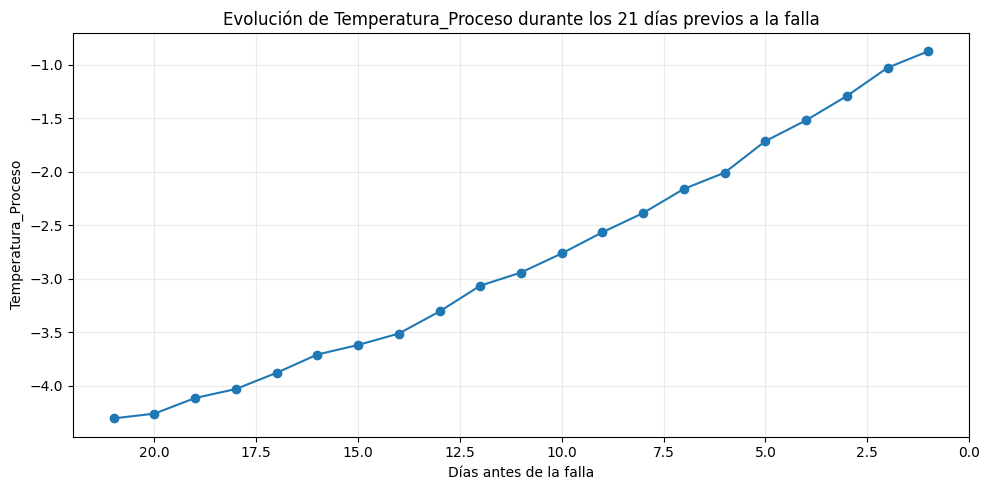

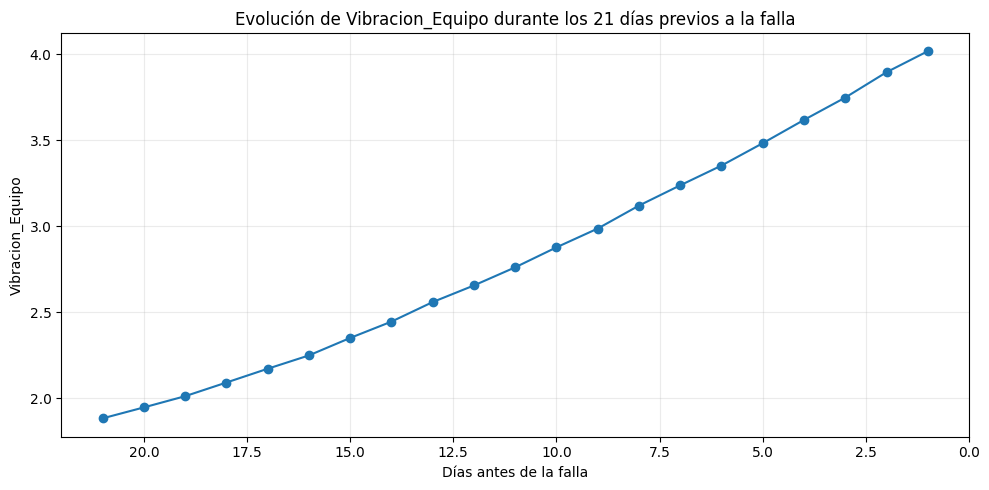

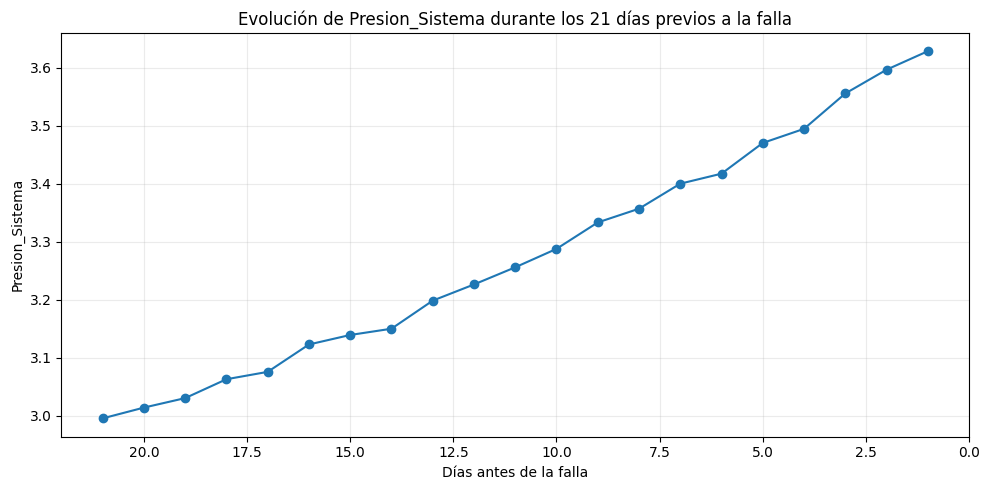

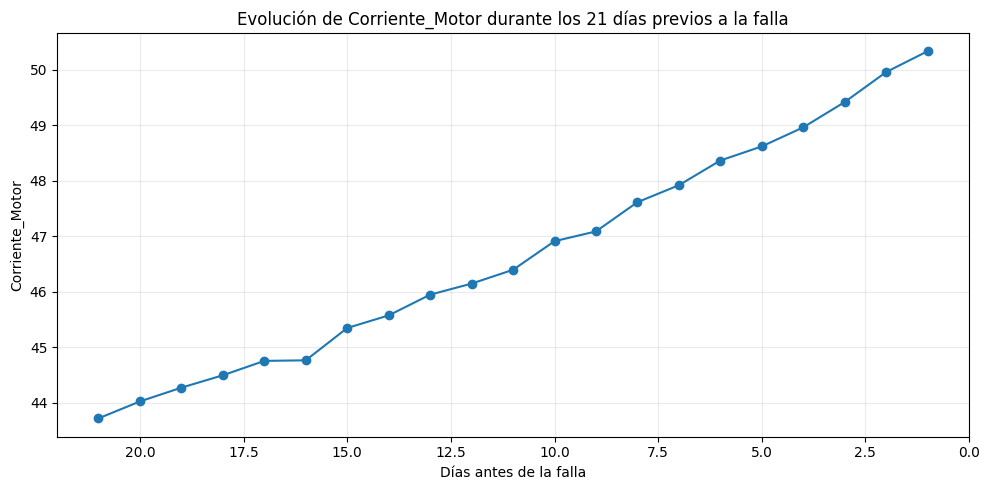

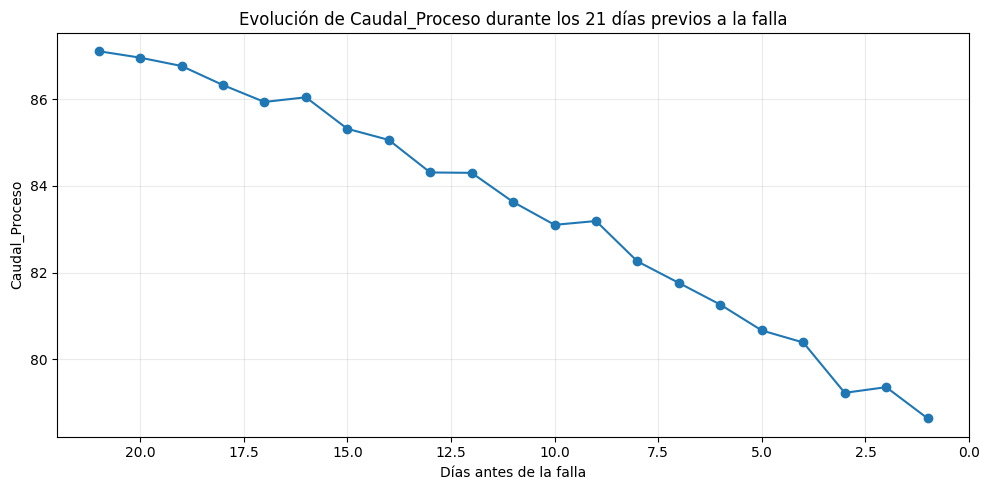

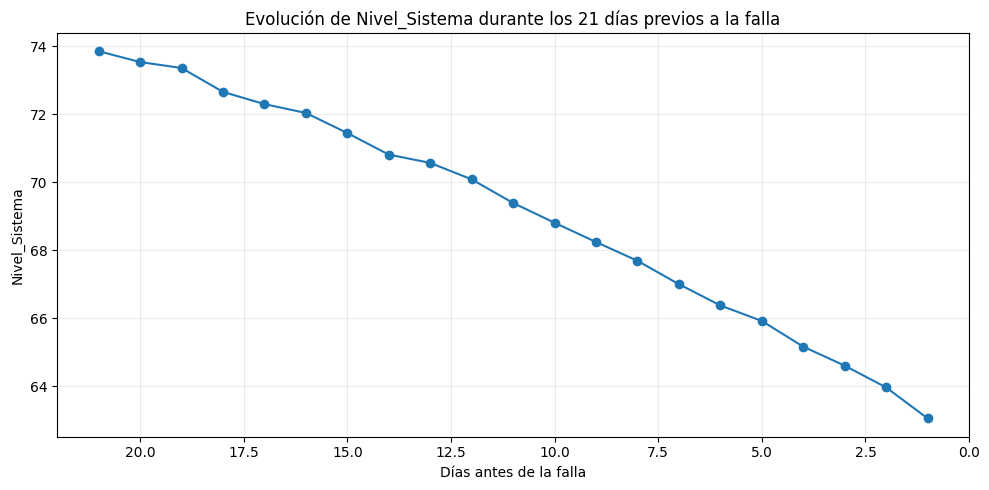

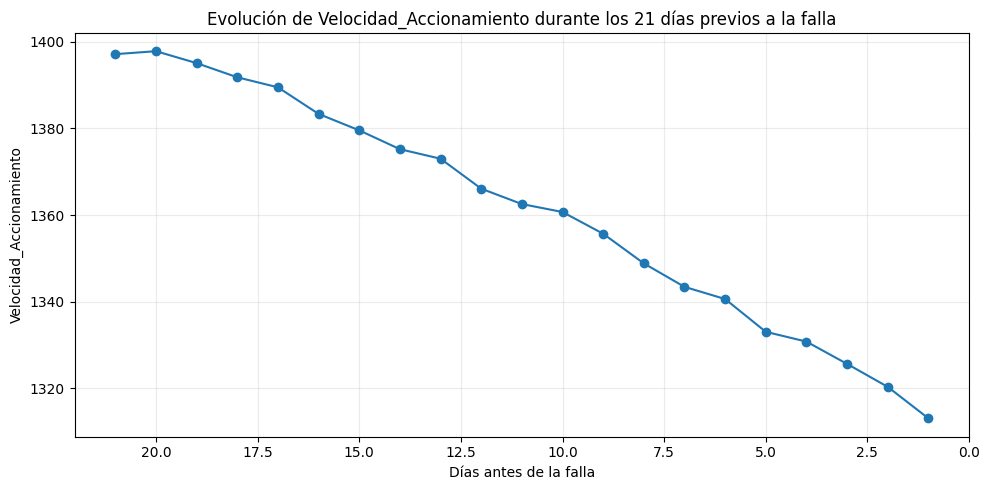

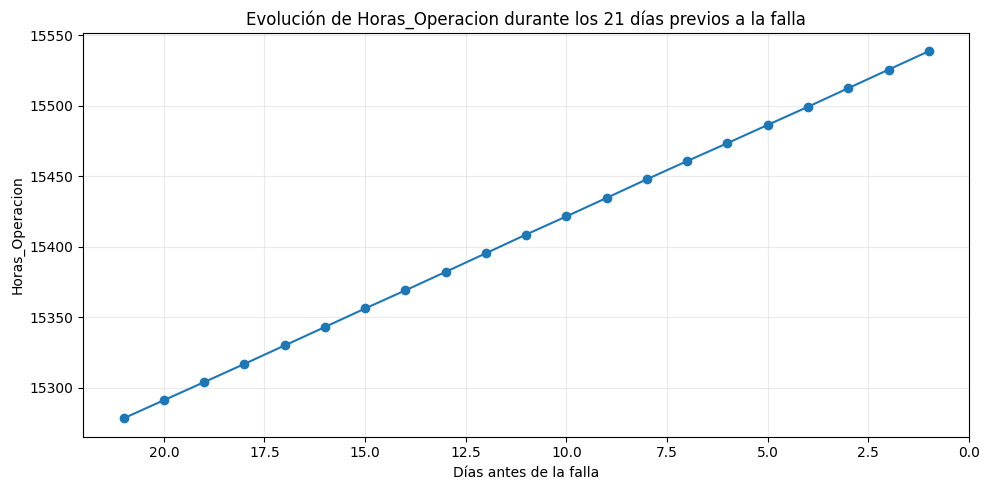


Análisis de evolución previa a la falla completado.


In [58]:
# Evolución previa a la falla

# Preparar fechas y equipos

obs["_Equipo_Clave"] = (
    obs["Identificador_Equipo"]
    .astype(str)
    .str.strip()
)

fallas["_Equipo_Clave"] = (
    fallas["Identificador_Equipo"]
    .astype(str)
    .str.strip()
)

fallas["Fecha_Falla"] = pd.to_datetime(
    fallas["Fecha_Falla"],
    errors="coerce"
).dt.normalize()

obs["Fecha_Observacion"] = pd.to_datetime(
    obs["Fecha_Observacion"],
    errors="coerce"
).dt.normalize()

fallas_validas = (
    fallas
    .dropna(
        subset=[
            "_Equipo_Clave",
            "Fecha_Falla"
        ]
    )
    .drop_duplicates(
        subset=[
            "_Equipo_Clave",
            "Fecha_Falla"
        ]
    )
    .copy()
)

print("Eventos válidos para el análisis:")
print(f"  {len(fallas_validas):,}")

# Construir ventanas de los 21 días previos

filas_previas = []

for _, evento in fallas_validas.iterrows():
    equipo = evento["_Equipo_Clave"]
    fecha_falla = evento["Fecha_Falla"]

    grupo = obs[
        (obs["_Equipo_Clave"] == equipo) &
        (obs["Fecha_Observacion"] < fecha_falla) &
        (
            obs["Fecha_Observacion"]
            >= fecha_falla - pd.Timedelta(days=21)
        )
    ].copy()

    if grupo.empty:
        continue

    grupo["Dias_Antes_Falla"] = (
        fecha_falla - grupo["Fecha_Observacion"]
    ).dt.days

    grupo["Fecha_Falla_Referencia"] = fecha_falla

    grupo["ID_Evento_Falla"] = (
        equipo
        + "_"
        + fecha_falla.strftime("%Y-%m-%d")
    )

    filas_previas.append(grupo)

if not filas_previas:
    print("\nNo se encontraron observaciones previas a las fallas.")

else:
    prev = pd.concat(
        filas_previas,
        ignore_index=True
    )

    print("\nAnálisis de los 21 días previos a la falla")
    print(f"Observaciones analizadas: {len(prev):,}")
    print(f"Equipos involucrados: {prev['_Equipo_Clave'].nunique():,}")
    print(f"Eventos de falla analizados: {len(fallas_validas):,}")

    # Variables operativas

    variables_previas = [
        "Temperatura_Proceso",
        "Vibracion_Equipo",
        "Presion_Sistema",
        "Corriente_Motor",
        "Caudal_Proceso",
        "Nivel_Sistema",
        "Velocidad_Accionamiento",
        "Horas_Operacion"
    ]

    variables_previas = [
        v for v in variables_previas
        if v in prev.columns
    ]

    for variable in variables_previas:
        prev[variable] = pd.to_numeric(
            prev[variable],
            errors="coerce"
        )

    # Resumen temporal

    resumen_temporal = (
        prev
        .groupby("Dias_Antes_Falla")[variables_previas]
        .mean()
        .reset_index()
        .sort_values("Dias_Antes_Falla")
    )

    print("\nPromedios de las variables según días antes de la falla:")
    display(resumen_temporal.round(3))

    # Gráficos de evolución

    for variable in variables_previas:
        datos_temporales = (
            prev
            .groupby("Dias_Antes_Falla")[variable]
            .mean()
            .reset_index()
            .sort_values("Dias_Antes_Falla")
        )

        if datos_temporales.empty:
            continue

        fig, ax = plt.subplots(figsize=(10, 5))

        ax.plot(
            datos_temporales["Dias_Antes_Falla"],
            datos_temporales[variable],
            marker="o"
        )

        ax.invert_xaxis()

        ax.set_xlabel("Días antes de la falla")
        ax.set_ylabel(variable)
        ax.set_title(
            f"Evolución de {variable} "
            "durante los 21 días previos a la falla"
        )
        ax.grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

    print("\nAnálisis de evolución previa a la falla completado.")


## 21. Validación de la construcción del horizonte de 7 días

Se comprueba que la variable objetivo tenga la estructura esperada: las observaciones positivas corresponden a equipos que presentan una falla durante los siete días posteriores y los últimos días del período quedan sin horizonte completo.

In [59]:
# Validación del target de 7 días

# Datos principales

df_diario = obs
df_eventos = fallas

target = TARGET
horizonte = "Tiene_Horizonte_Completo_Siete_Dias"

# Distribución del target

print("Distribución del target")

distribucion_target = (
    df_diario[target]
    .value_counts(dropna=False)
    .rename_axis("Valor_Target")
    .reset_index(name="Cantidad")
)

distribucion_target["Porcentaje"] = (
    distribucion_target["Cantidad"]
    / len(df_diario)
    * 100
)

display(distribucion_target.round(2))

# Horizonte completo

if horizonte in df_diario.columns:
    print("\nHorizonte completo de 7 días")

    distribucion_horizonte = (
        df_diario[horizonte]
        .value_counts(dropna=False)
        .rename_axis("Horizonte_Completo")
        .reset_index(name="Cantidad")
    )

    distribucion_horizonte["Porcentaje"] = (
        distribucion_horizonte["Cantidad"]
        / len(df_diario)
        * 100
    )

    display(distribucion_horizonte.round(2))

# Rango temporal

fecha_min = df_diario["Fecha_Observacion"].min()
fecha_max = df_diario["Fecha_Observacion"].max()

print("\nRango temporal")
print(f"Primera fecha de observación: {fecha_min.strftime('%d/%m/%Y')}")
print(f"Última fecha de observación: {fecha_max.strftime('%d/%m/%Y')}")

# Resumen del target

positivos = int(df_diario[target].eq(1).sum())
negativos = int(df_diario[target].eq(0).sum())
sin_horizonte = int(df_diario[target].isna().sum())

print("\nResumen del target")
print(f"Observaciones con target = 1 : {positivos:,}")
print(f"Observaciones con target = 0 : {negativos:,}")
print(f"Observaciones sin target     : {sin_horizonte:,}")
print(f"Total de observaciones       : {len(df_diario):,}")

# Validación de las ventanas de 7 días

print("\nValidación de las ventanas de 7 días")

cantidad_eventos = len(df_eventos)
positivos_esperados = cantidad_eventos * 7

print(f"Eventos de falla registrados : {cantidad_eventos:,}")
print(f"Eventos × 7 días             : {positivos_esperados:,}")
print(f"Observaciones positivas      : {positivos:,}")

if positivos == positivos_esperados:
    print(
        "\nLa cantidad de observaciones positivas "
        "coincide con 7 observaciones por evento."
    )
else:
    print(
        "\nLa cantidad de positivos no coincide "
        "exactamente con eventos × 7."
    )

# Últimos 7 días

print("\nÚltimos 7 días del dataset")

ultimos_7 = (
    df_diario[
        df_diario["Fecha_Observacion"]
        >= fecha_max - pd.Timedelta(days=6)
    ]
    .sort_values("Fecha_Observacion")
)

resumen_ultimos_7 = (
    ultimos_7
    .groupby("Fecha_Observacion")
    .agg(
        Observaciones=("Fecha_Observacion", "size"),
        Target_NaN=(target, lambda x: x.isna().sum()),
        Target_0=(target, lambda x: (x == 0).sum()),
        Target_1=(target, lambda x: (x == 1).sum())
    )
    .reset_index()
)

display(resumen_ultimos_7)

# Regla temporal

print("\nRegla metodológica:")
print(
    "Cada observación Equipo-Día utiliza únicamente "
    "la información disponible hasta el cierre de ese día."
)
print(
    "La ocurrencia de una falla durante los siete días "
    "posteriores se utiliza exclusivamente para construir "
    "la variable objetivo."
)

print("\nValidación del target de 7 días completada.")


Distribución del target


,Valor_Target,Cantidad,Porcentaje
0,0.0,15570,87.87
1,1.0,1946,10.98
2,NaN,203,1.15



Horizonte completo de 7 días


,Horizonte_Completo,Cantidad,Porcentaje
0,True,17516,98.85
1,False,203,1.15



Rango temporal
Primera fecha de observación: 01/01/2025
Última fecha de observación: 03/09/2026

Resumen del target
Observaciones con target = 1 : 1,946
Observaciones con target = 0 : 15,570
Observaciones sin target     : 203
Total de observaciones       : 17,719

Validación de las ventanas de 7 días
Eventos de falla registrados : 278
Eventos × 7 días             : 1,946
Observaciones positivas      : 1,946

La cantidad de observaciones positivas coincide con 7 observaciones por evento.

Últimos 7 días del dataset


,Fecha_Observacion,Observaciones,Target_NaN,Target_0,Target_1
0,2026-08-28,29,29,0,0
1,2026-08-29,29,29,0,0
2,2026-08-30,29,29,0,0
3,2026-08-31,29,29,0,0
4,2026-09-01,29,29,0,0
5,2026-09-02,29,29,0,0
6,2026-09-03,29,29,0,0



Regla metodológica:
Cada observación Equipo-Día utiliza únicamente la información disponible hasta el cierre de ese día.
La ocurrencia de una falla durante los siete días posteriores se utiliza exclusivamente para construir la variable objetivo.

Validación del target de 7 días completada.


## 22. Matriz explícita de variables y riesgo de fuga de información

Antes del modelado se documenta qué variables pueden utilizarse como predictores y cuáles deben excluirse por contener información futura, posterior al evento o derivada del objetivo.

In [60]:
# Matriz de fuga de información

columnas = list(obs.columns)

reglas = []

for c in columnas:
    lc = c.lower()

    if c == TARGET:
        decision = "EXCLUIR"
        motivo = "Variable objetivo del modelo"

    elif any(
        x in lc
        for x in [
            "falla_registrada",
            "tipo_falla",
            "severidad",
            "fecha_falla",
            "vida_útil",
            "vida_util",
            "probabilidad_falla"
        ]
    ):
        decision = "EXCLUIR"
        motivo = "Puede contener información del evento o una variable derivada"

    elif c in [
        "Tiene_Horizonte_Completo_Siete_Dias",
        "Conjunto_Temporal"
    ]:
        decision = "CONTROL"
        motivo = "Variable metodológica; no debe utilizarse como predictor"

    elif c in [
        "Identificador_Equipo",
        "Codigo_Equipo_Origen",
        "Nombre_Equipo"
    ]:
        decision = "REVISAR"
        motivo = "Identificación o categoría; requiere codificación o exclusión"

    elif c == "Fecha_Observacion":
        decision = "REVISAR"
        motivo = "Puede transformarse en variables temporales sin usar información futura"

    else:
        decision = "CANDIDATA"
        motivo = "Información disponible al cierre de la observación"

    reglas.append({
        "Variable": c,
        "Decisión": decision,
        "Justificación": motivo
    })

matriz_fuga = pd.DataFrame(reglas)

display(matriz_fuga)


,Variable,Decisión,Justificación
0,Identificador_Equipo,REVISAR,Identificación o categoría; requiere codificac...
1,Codigo_Equipo_Origen,REVISAR,Identificación o categoría; requiere codificac...
2,Nombre_Equipo,REVISAR,Identificación o categoría; requiere codificac...
3,Tipo_Equipo,CANDIDATA,Información disponible al cierre de la observa...
4,Proceso,CANDIDATA,Información disponible al cierre de la observa...
5,Línea,CANDIDATA,Información disponible al cierre de la observa...
6,Criticidad,CANDIDATA,Información disponible al cierre de la observa...
7,Fecha_Observacion,REVISAR,Puede transformarse en variables temporales si...
8,Temperatura_Proceso,CANDIDATA,Información disponible al cierre de la observa...
9,Vibracion_Equipo,CANDIDATA,Información disponible al cierre de la observa...


## 23. Preparación de insumos para la Fase 3

La Fase 2 finaliza con una selección preliminar de variables operativas y controles metodológicos. No se realiza todavía entrenamiento de modelos.

In [61]:
# Insumos para la Fase 3

predictores_preliminares = [
    "Temperatura_Proceso",
    "Vibracion_Equipo",
    "Presion_Sistema",
    "Corriente_Motor",
    "Caudal_Proceso",
    "Nivel_Sistema",
    "Velocidad_Accionamiento",
    "Horas_Operacion"
]

predictores_preliminares = [
    c for c in predictores_preliminares
    if c in obs.columns
]

print("Predictores operativos preliminares:")

for c in predictores_preliminares:
    print(" -", c)

print("\nVariable objetivo:")
print(" -", TARGET)

print("\nRegla temporal:")
print(
    "Los predictores corresponden únicamente a información "
    "disponible hasta el cierre de cada Equipo-Día."
)
print(
    "La falla de los siete días posteriores se utiliza "
    "exclusivamente para construir la etiqueta."
)


Predictores operativos preliminares:
 - Temperatura_Proceso
 - Vibracion_Equipo
 - Presion_Sistema
 - Corriente_Motor
 - Caudal_Proceso
 - Nivel_Sistema
 - Velocidad_Accionamiento
 - Horas_Operacion

Variable objetivo:
 - Falla_En_Los_Siguientes_Siete_Dias

Regla temporal:
Los predictores corresponden únicamente a información disponible hasta el cierre de cada Equipo-Día.
La falla de los siete días posteriores se utiliza exclusivamente para construir la etiqueta.


## 24. Principales hallazgos

Relación de fallas con el proceso
Eventos sin proceso asociado: 0

Distribución de fallas por proceso


,Proceso,Cantidad_Fallas,Porcentaje
3,Preparación,87,31.29
2,Envasado,76,27.34
1,Congelación,58,20.86
4,Refrigeración,38,13.67
0,Almacenamiento,19,6.83


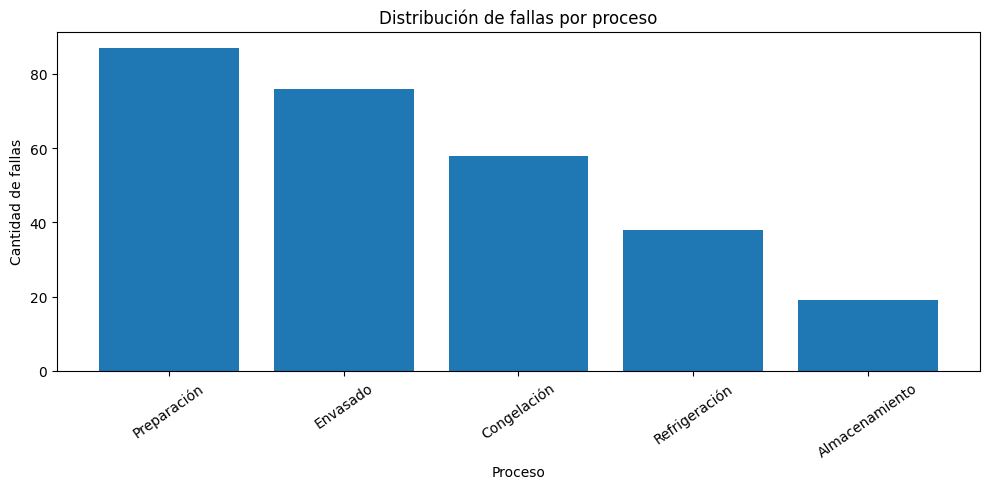


Principales hallazgos
1. El conjunto de datos estructurado bajo la unidad de análisis Equipo-Día contiene 17,719 observaciones y 20 variables.
2. Se identificaron 29 equipos.
3. El período de observación comprende desde 2025-01-01 hasta 2026-09-03.
4. La variable objetivo presenta 15,570 observaciones con valor 0, 1,946 con valor 1 y 203 sin etiqueta.
5. La variable con mayor proporción de valores faltantes es Falla_En_Los_Siguientes_Siete_Dias con 1.15%.
6. Se detectaron 0 registros completamente duplicados.
7. La mayor proporción de posibles valores atípicos según el criterio IQR corresponde a Presion_Sistema (6.49%).
8. El registro histórico contiene 278 eventos de falla.
9. El proceso con mayor cantidad de eventos de falla es Preparación, con 87 eventos (31.29%).

Principales hallazgos exportados correctamente.


In [62]:
# Principales hallazgos

hallazgos = []

# Estructura Equipo-Día

hallazgos.append(
    f"El conjunto de datos estructurado bajo la unidad de análisis "
    f"Equipo-Día contiene {len(obs):,} observaciones y "
    f"{obs.shape[1]:,} variables."
)

# Cantidad de equipos

hallazgos.append(
    f"Se identificaron {obs['Identificador_Equipo'].nunique():,} equipos."
)

# Período de observación

hallazgos.append(
    f"El período de observación comprende desde "
    f"{obs['Fecha_Observacion'].min().date()} "
    f"hasta {obs['Fecha_Observacion'].max().date()}."
)

# Distribución del target

hallazgos.append(
    f"La variable objetivo presenta {n0:,} observaciones con valor 0, "
    f"{n1:,} con valor 1 y {ns:,} sin etiqueta."
)

# Valores faltantes

if not faltantes.empty:
    top = (
        faltantes
        .sort_values(
            "Porcentaje_Nulos",
            ascending=False
        )
        .iloc[0]
    )

    hallazgos.append(
        f"La variable con mayor proporción de valores faltantes es "
        f"{top['Variable']} con {top['Porcentaje_Nulos']:.2f}%."
    )
else:
    hallazgos.append(
        "No se identificaron valores faltantes en las variables revisadas."
    )

# Registros duplicados

hallazgos.append(
    f"Se detectaron "
    f"{int(duplicados['Duplicados_Completos'].sum()):,} "
    f"registros completamente duplicados."
)

# Valores atípicos

if not outliers.empty:
    top_out = (
        outliers
        .sort_values(
            "Porcentaje_Outliers",
            ascending=False
        )
        .iloc[0]
    )

    hallazgos.append(
        f"La mayor proporción de posibles valores atípicos "
        f"según el criterio IQR corresponde a "
        f"{top_out['Variable']} "
        f"({top_out['Porcentaje_Outliers']:.2f}%)."
    )
else:
    hallazgos.append(
        "No se identificaron variables con posibles valores atípicos "
        "según el criterio IQR."
    )

# Eventos históricos de falla

hallazgos.append(
    f"El registro histórico contiene {len(fallas):,} eventos de falla."
)

# Relacionar fallas con procesos

if (
    "Identificador_Equipo" in fallas.columns
    and "Identificador_Equipo" in equipos.columns
    and "Proceso" in equipos.columns
):

    fallas_proceso = fallas[
        ["Identificador_Equipo"]
    ].merge(
        equipos[
            [
                "Identificador_Equipo",
                "Proceso"
            ]
        ].drop_duplicates(
            subset=["Identificador_Equipo"]
        ),
        on="Identificador_Equipo",
        how="left"
    )

    sin_proceso = fallas_proceso["Proceso"].isna().sum()

    print("Relación de fallas con el proceso")
    print(f"Eventos sin proceso asociado: {sin_proceso:,}")

    fallas_por_proceso = (
        fallas_proceso
        .groupby(
            "Proceso",
            dropna=False
        )
        .size()
        .reset_index(
            name="Cantidad_Fallas"
        )
        .sort_values(
            "Cantidad_Fallas",
            ascending=False
        )
    )

    fallas_por_proceso["Porcentaje"] = (
        fallas_por_proceso["Cantidad_Fallas"]
        / len(fallas_proceso)
        * 100
    )

    print("\nDistribución de fallas por proceso")
    display(fallas_por_proceso.round(2))

    # Gráfico por proceso

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(
        fallas_por_proceso["Proceso"].astype(str),
        fallas_por_proceso["Cantidad_Fallas"]
    )

    ax.set_xlabel("Proceso")
    ax.set_ylabel("Cantidad de fallas")
    ax.set_title("Distribución de fallas por proceso")

    ax.tick_params(
        axis="x",
        rotation=35
    )

    plt.tight_layout()
    plt.show()

    # Hallazgo principal

    if not fallas_por_proceso.empty:
        top_proceso = fallas_por_proceso.iloc[0]

        hallazgos.append(
            f"El proceso con mayor cantidad de eventos de falla es "
            f"{top_proceso['Proceso']}, con "
            f"{int(top_proceso['Cantidad_Fallas']):,} eventos "
            f"({top_proceso['Porcentaje']:.2f}%)."
        )

else:
    hallazgos.append(
        "No fue posible obtener la distribución de fallas por proceso "
        "debido a la ausencia de las columnas necesarias."
    )

# Mostrar hallazgos

print("\nPrincipales hallazgos")

for i, h in enumerate(hallazgos, 1):
    print(f"{i}. {h}")

# Guardar resultados

pd.DataFrame({
    "Hallazgo": hallazgos
}).to_csv(
    TABLAS_DIR / "17_principales_hallazgos.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nPrincipales hallazgos exportados correctamente.")


## 25. Implicaciones para la Fase 3 – Preparación de los datos

Los hallazgos anteriores deberán utilizarse para justificar las decisiones de la sección 7.3. En particular, se deberá considerar el tratamiento de valores faltantes y atípicos, la validación de variables temporales, la selección de predictores disponibles al momento de observación y la prevención de fuga de información.

Los resultados definitivos de la monografía deben basarse en las salidas obtenidas al ejecutar este notebook.

In [63]:


print("FIGURAS GENERADAS:")
for f in sorted(FIGURAS_DIR.iterdir()):
    print("-", f.name)

print("\nTABLAS GENERADAS:")
for f in sorted(TABLAS_DIR.iterdir()):
    print("-", f.name)

FIGURAS GENERADAS:
- 01_variable_objetivo.png
- 02_hist_Caudal_Proceso.png
- 02_hist_Corriente_Motor.png
- 02_hist_Horas_Operacion.png
- 02_hist_Nivel_Sistema.png
- 02_hist_Presion_Sistema.png
- 02_hist_Temperatura_Proceso.png
- 02_hist_Velocidad_Accionamiento.png
- 02_hist_Vibracion_Equipo.png
- 03_matriz_correlacion.png
- 04_fallas_por_mes.png
- 05_fallas_por_equipo.png

TABLAS GENERADAS:
- 01_inventario.csv
- 02_variables_tipos_calidad.csv
- 03_valores_faltantes.csv
- 04_duplicados.csv
- 05_revision_fechas.csv
- 06_frecuencias_categoricas.csv
- 07_estadistica_descriptiva.csv
- 08_variable_objetivo.csv
- 09_outliers_IQR.csv
- 10_matriz_correlacion.csv
- 11_comparacion_por_falla.csv
- 12_fallas_por_mes.csv
- 13_fallas_por_equipo.csv
- 14_fallas_por_tipo_equipo.csv
- 15_fallas_por_criticidad.csv
- 16_cobertura_sensores.csv
- 17_principales_hallazgos.csv
